In [2]:
from imports import *

artists = pd.read_parquet("tmp/p01_artists.parquet")
tracks = pd.read_parquet("tmp/tracks_with_embeddings.parquet")

X_tsne2 = pd.read_parquet("tmp/X_tsne2.parquet")
X_tsne3 = pd.read_parquet("tmp/X_tsne3.parquet")

X_umap3 = pd.read_parquet("tmp/X_umap3.parquet")
X_umap5 = pd.read_parquet("tmp/X_umap5.parquet")
X_umap8 = pd.read_parquet("tmp/X_umap8.parquet")

pca_audio_cols = pickle.load(open("tmp/pca_audio_cols.pkl", "rb"))
pca_clust_cols = pickle.load(open("tmp/pca_clust_cols.pkl", "rb"))
emb_cols = pickle.load(open("tmp/emb_cols.pkl", "rb"))

In [3]:
def dbscan_test(X):
    for min_samples in range(5, 55, 5):
    
        # elbow method
        neigh = NearestNeighbors(n_neighbors=min_samples+1)
        neigh.fit(X) # X is normalized
        distances, indices = neigh.kneighbors(X)
        k_dist = distances[:, min_samples]
        k_dist = np.sort(k_dist, axis=0)
        
        start_eps, elbow_index = find_elbow_point(k_dist)
        
        for div in [0.8, 0.9, 1, 1.1, 1.2]:
            eps = start_eps / div
            
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            dbscan.fit(X)
            np.unique(dbscan.labels_, return_counts=True)
            
            labels = dbscan.labels_
            unique_labels = set(labels)
    
            n_clusters = len(unique_labels)
            
            if -1 in unique_labels:
                n_clusters -= 1

            print(f'\nmin_samples = {min_samples}, eps = {eps}, clusters = {n_clusters}')
            if n_clusters > 1:
                
                sscore = metrics.silhouette_score(X, dbscan.labels_)
    
                if sscore > 0:

                    plt.figure(figsize=(10, 6))
                    plt.plot(k_dist)
                    plt.plot(elbow_index, start_eps, 'ro', label=f'Elbow Point (Eps ≈ {start_eps:.3f})')
                    plt.vlines(elbow_index, 0, start_eps, linestyle="--", color='r', alpha=0.5)
                    plt.xlabel("Points Sorted by Distance")
                    plt.ylabel(f"Distance to the {min_samples}-th Nearest Neighbor")
                    plt.title(f"K-Distance Graph (min_samples = {min_samples})")
                    plt.show()
                    plt.figure(figsize=(7,5))
                    sns.scatterplot(data=X, x=X.columns[0], y=X.columns[1], hue=labels)
                    plt.title(f"eps = {eps:.4f}, clusters = {n_clusters}")
                    plt.show()
                
                X_array = X.to_numpy(dtype='double') if hasattr(X, 'to_numpy') else X.astype('double')
    
                labels = dbscan.labels_ 
            
                unique_labels, counts = np.unique(labels, return_counts=True)
                valid_labels = unique_labels[(unique_labels != -1) & (counts > 1)]
                
                mask = np.isin(labels, valid_labels)
                
                if np.sum(mask) != 0:
                    clean_X = X_array[mask]
                    clean_labels = labels[mask]
                
                    try:
                        sil = metrics.silhouette_score(X_array, labels)
                        print(f'Silhouette: {sil:.4f}')
                        
                        dbcv = hdbscan.validity.validity_index(clean_X, clean_labels)
                        print(f"DBCV: {dbcv:.4f}")
                    except Exception as e:
                        print(f"Error calculating metrics: {e}")
                print("______________________________________________________________________")

    return dbscan.labels_
            

In [4]:
def hdbscan_test(df, min_cluster_size=50, min_samples=4, plot=False):
    # Fix 1: Cast to float64 to prevent "Buffer dtype mismatch"
    X_matrix = df.values.astype(np.float64) 
    
    model = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size, 
        min_samples=min_samples, 
        metric='euclidean', 
        cluster_selection_method='eom'
    )
    
    labels = model.fit_predict(X_matrix)
    df['cluster'] = labels 
    
    mask = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    
    if n_clusters > 1:
        X_core = X_matrix[mask]
        labels_core = labels[mask]
        
        sil = metrics.silhouette_score(X_core, labels_core)
        sep = metrics.davies_bouldin_score(X_core, labels_core)
        
        # The cast above ensures X_core is float64 here
        dbcv = hdbscan.validity.validity_index(X_core, labels_core)
        
        print(f"Method: hdbscan, Clusters = {n_clusters}, Noise = {n_noise}, "
              f"DBCV={dbcv:.5f}, Sil={sil:.5f}, Sep={sep:.5f}")
    else:
        print(f"Method: hdbscan, Clusters = {n_clusters}, Noise = {n_noise} (Insufficient for metrics)")

    if plot:
        try:
            plt.clf()
            fig, ax = plt.subplots(figsize=(10, 5))
            
            # Use a more robust palette handling
            current_palette = sns.color_palette('deep', n_clusters if n_clusters > 0 else 1)
            
            model.condensed_tree_.plot(
                select_clusters=True, 
                selection_palette=current_palette,
                axis=ax
            )
            
            plt.title(f"MCS={min_cluster_size}, MS={min_samples}")
            plt.show()
            plt.close(fig)
        except Exception as e:
            print(f"Plotting failed due to Matplotlib/HDBSCAN compatibility: {e}")
            plt.close() # Clean up the failed figure

    return labels


min_samples = 5, eps = 1.6147897994274374, clusters = 1

min_samples = 5, eps = 1.4353687106021666, clusters = 1

min_samples = 5, eps = 1.29183183954195, clusters = 2


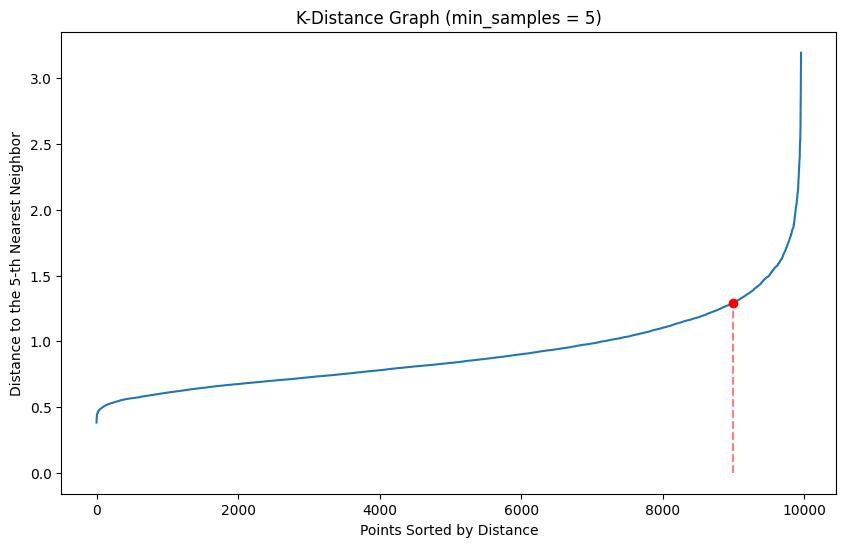

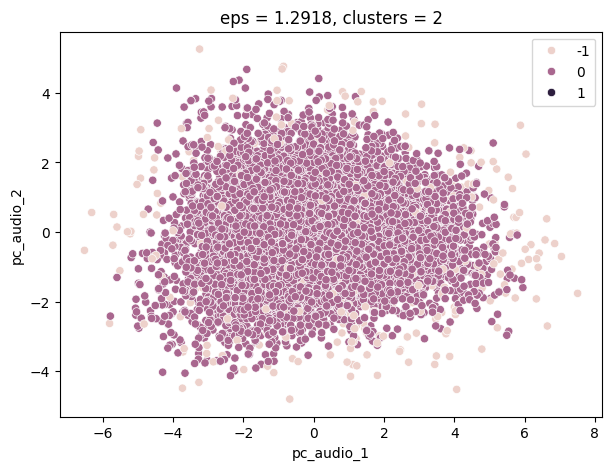

Silhouette: 0.2178
DBCV: -0.2899
______________________________________________________________________

min_samples = 5, eps = 1.1743925814017726, clusters = 4
Silhouette: -0.0074
DBCV: -0.3768
______________________________________________________________________

min_samples = 5, eps = 1.076526532951625, clusters = 9
Silhouette: -0.0232
DBCV: -0.3810
______________________________________________________________________

min_samples = 10, eps = 1.8345538745328687, clusters = 1

min_samples = 10, eps = 1.6307145551403277, clusters = 1

min_samples = 10, eps = 1.467643099626295, clusters = 1

min_samples = 10, eps = 1.334220999660268, clusters = 1

min_samples = 10, eps = 1.223035916355246, clusters = 2


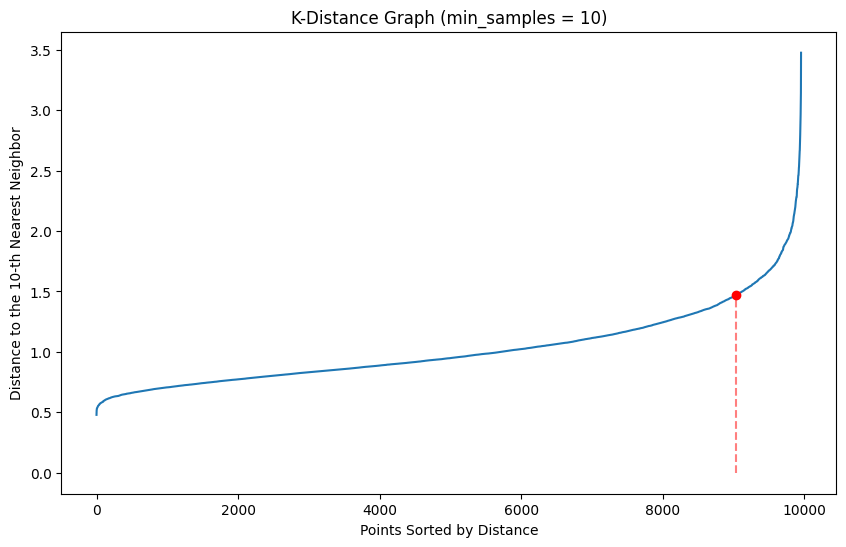

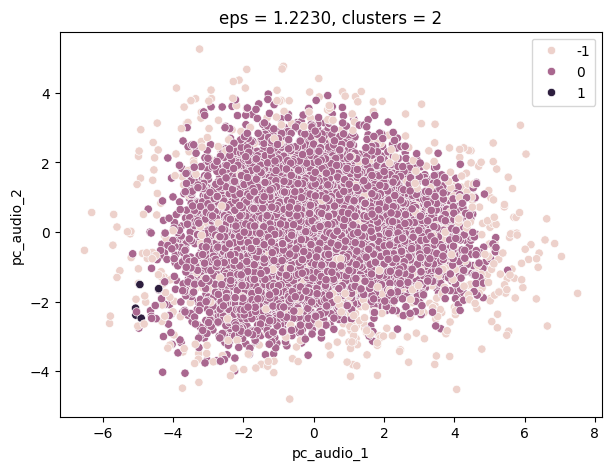

Silhouette: 0.2116
DBCV: -0.2230
______________________________________________________________________

min_samples = 15, eps = 1.9496491918786185, clusters = 1

min_samples = 15, eps = 1.7330215038921053, clusters = 1

min_samples = 15, eps = 1.5597193535028948, clusters = 1

min_samples = 15, eps = 1.4179266850026315, clusters = 1

min_samples = 15, eps = 1.299766127919079, clusters = 1

min_samples = 20, eps = 2.0121642506457285, clusters = 1

min_samples = 20, eps = 1.7885904450184253, clusters = 1

min_samples = 20, eps = 1.6097314005165828, clusters = 1

min_samples = 20, eps = 1.4633921822878024, clusters = 1

min_samples = 20, eps = 1.3414428337638191, clusters = 1

min_samples = 25, eps = 2.0848024658418347, clusters = 1

min_samples = 25, eps = 1.8531577474149643, clusters = 1

min_samples = 25, eps = 1.667841972673468, clusters = 1

min_samples = 25, eps = 1.516219975157698, clusters = 1

min_samples = 25, eps = 1.3898683105612233, clusters = 1

min_samples = 30, eps = 2.11

array([ 0, -1,  0, ...,  0,  0,  0], shape=(9954,))

In [5]:
dbscan_test(tracks[pca_audio_cols])

In [ ]:
dbscan_test(tracks[pca_clust_cols])


min_samples = 5, eps = 3.0274562915510725, clusters = 1

min_samples = 5, eps = 2.6910722591565093, clusters = 1

min_samples = 5, eps = 2.421965033240858, clusters = 1

min_samples = 5, eps = 2.2017863938553255, clusters = 1

min_samples = 5, eps = 2.018304194367382, clusters = 1

min_samples = 10, eps = 3.434467792167498, clusters = 1

min_samples = 10, eps = 3.0528602597044427, clusters = 1

min_samples = 10, eps = 2.7475742337339986, clusters = 1

min_samples = 10, eps = 2.4977947579399986, clusters = 1

min_samples = 10, eps = 2.2896451947783323, clusters = 1

min_samples = 15, eps = 3.728335556968513, clusters = 1

min_samples = 15, eps = 3.3140760506386786, clusters = 1

min_samples = 15, eps = 2.9826684455748107, clusters = 1

min_samples = 15, eps = 2.711516768704373, clusters = 1

min_samples = 15, eps = 2.485557037979009, clusters = 1

min_samples = 20, eps = 3.8355058607689165, clusters = 1

min_samples = 20, eps = 3.409338542905704, clusters = 1

min_samples = 20, eps = 3


min_samples = 5, eps = 0.2666406271786584, clusters = 2
Silhouette: -0.0920
DBCV: -0.6648
______________________________________________________________________

min_samples = 5, eps = 0.2424005701624167, clusters = 7
Silhouette: -0.4424
DBCV: -0.6940
______________________________________________________________________

min_samples = 5, eps = 0.222200522648882, clusters = 20
Silhouette: -0.5628
DBCV: -0.6840
______________________________________________________________________

min_samples = 10, eps = 0.30235831592675116, clusters = 3
Silhouette: -0.2642
DBCV: -0.6351
______________________________________________________________________

min_samples = 10, eps = 0.2771617895995219, clusters = 6
Silhouette: -0.4321
DBCV: -0.6411
______________________________________________________________________

min_samples = 15, eps = 0.3083096929724571, clusters = 3
Silhouette: -0.2392
DBCV: -0.6809
______________________________________________________________________

min_samples = 20, eps =

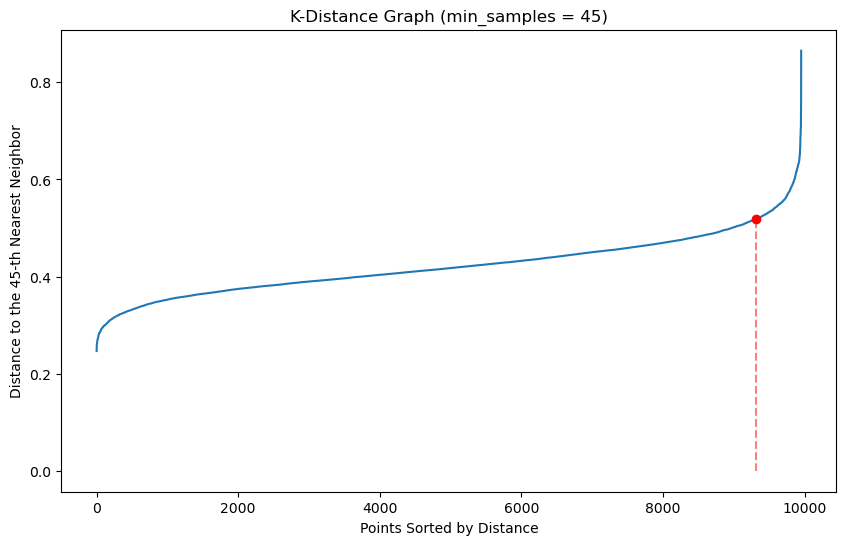

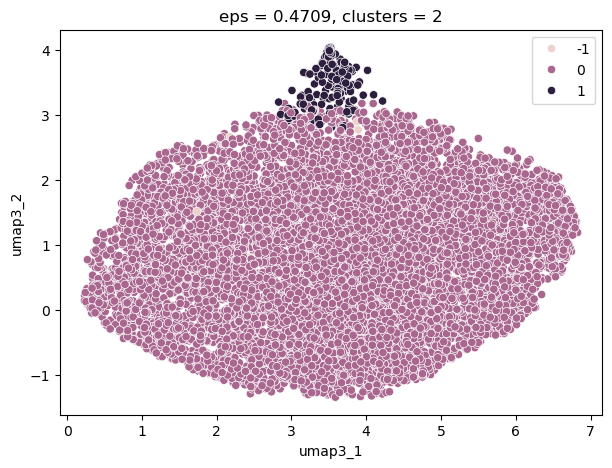

Silhouette: 0.0036
DBCV: -0.6624
______________________________________________________________________

min_samples = 45, eps = 0.4316135862301709, clusters = 2
Silhouette: -0.0480
DBCV: -0.6554
______________________________________________________________________

min_samples = 50, eps = 0.4828432010645581, clusters = 2
Silhouette: -0.0084
DBCV: -0.6564
______________________________________________________________________

min_samples = 50, eps = 0.4426062676425116, clusters = 2
Silhouette: -0.0432
DBCV: -0.6570
______________________________________________________________________


array([0, 0, 0, ..., 0, 0, 0], shape=(9954,))

In [ ]:
dbscan_test(X_umap3)

In [ ]:
dbscan_test(X_umap5)


min_samples = 5, eps = 0.5355965379657068, clusters = 1

min_samples = 5, eps = 0.4760858115250728, clusters = 3
Silhouette: -0.2252
DBCV: -0.4465
______________________________________________________________________

min_samples = 5, eps = 0.4284772303725655, clusters = 6
Silhouette: -0.3489
DBCV: -0.4907
______________________________________________________________________

min_samples = 5, eps = 0.38952475488415045, clusters = 14
Silhouette: -0.5106
DBCV: -0.6234
______________________________________________________________________

min_samples = 5, eps = 0.3570643586438046, clusters = 34
Silhouette: -0.5390
DBCV: -0.6231
______________________________________________________________________

min_samples = 10, eps = 0.6310400956009665, clusters = 1

min_samples = 10, eps = 0.5609245294230814, clusters = 1

min_samples = 10, eps = 0.5048320764807732, clusters = 1

min_samples = 10, eps = 0.45893825134615746, clusters = 1

min_samples = 10, eps = 0.420693397067311, clusters = 3
Si

array([0, 0, 0, ..., 0, 0, 0], shape=(9954,))

In [ ]:
dbscan_test(X_umap8)


min_samples = 5, eps = 0.5803220080648869, clusters = 1

min_samples = 5, eps = 0.5158417849465661, clusters = 2
Silhouette: -0.2005
DBCV: -0.4822
______________________________________________________________________

min_samples = 5, eps = 0.4642576064519095, clusters = 7
Silhouette: -0.3867
DBCV: -0.5025
______________________________________________________________________

min_samples = 5, eps = 0.42205236950173586, clusters = 12
Silhouette: -0.4580
DBCV: -0.4828
______________________________________________________________________

min_samples = 5, eps = 0.3868813387099246, clusters = 33
Silhouette: -0.5333
DBCV: -0.5250
______________________________________________________________________

min_samples = 10, eps = 0.6878847060669008, clusters = 1

min_samples = 10, eps = 0.6114530720594673, clusters = 1

min_samples = 10, eps = 0.5503077648535206, clusters = 1

min_samples = 10, eps = 0.5002797862304732, clusters = 2
Silhouette: -0.2266
DBCV: -0.3769
__________________________

array([0, 0, 0, ..., 0, 0, 0], shape=(9954,))

In [ ]:
dbscan_test(tracks[emb_cols])


min_samples = 5, eps = 1.0647159069776535, clusters = 1

min_samples = 5, eps = 0.946414139535692, clusters = 1

min_samples = 5, eps = 0.8517727255821228, clusters = 1

min_samples = 5, eps = 0.7743388414382933, clusters = 1

min_samples = 5, eps = 0.709810604651769, clusters = 3
Silhouette: -0.0002


/usr/lib/python3.13/site-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[
/usr/lib/python3.13/site-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[


DBCV: 0.0181
______________________________________________________________________

min_samples = 10, eps = 1.093544214963913, clusters = 1

min_samples = 10, eps = 0.9720393021901448, clusters = 1

min_samples = 10, eps = 0.8748353719711304, clusters = 1

min_samples = 10, eps = 0.7953048836101184, clusters = 1

min_samples = 10, eps = 0.7290294766426086, clusters = 1

min_samples = 15, eps = 1.1052719503641129, clusters = 1

min_samples = 15, eps = 0.9824639558792114, clusters = 1

min_samples = 15, eps = 0.8842175602912903, clusters = 1

min_samples = 15, eps = 0.8038341457193547, clusters = 1

min_samples = 15, eps = 0.7368479669094086, clusters = 1

min_samples = 20, eps = 1.111065000295639, clusters = 1

min_samples = 20, eps = 0.9876133335961236, clusters = 1

min_samples = 20, eps = 0.8888520002365112, clusters = 1

min_samples = 20, eps = 0.8080472729422828, clusters = 1

min_samples = 20, eps = 0.7407100001970928, clusters = 1

min_samples = 25, eps = 1.1207225918769836, clu

array([-1, -1,  0, ..., -1,  0, -1], shape=(9954,))

DBScan does not seem to bring interesting results... Let's try hdbscan.

min_samples = 1
Method: hdbscan, Clusters = 13, Noise = 4534, DBCV=-0.40123, Sil=0.26469, Sep=0.96693


<Figure size 640x480 with 0 Axes>

ValueError: setting an array element with a sequence.

<Figure size 1000x500 with 2 Axes>

min_samples = 5
Method: hdbscan, Clusters = 14, Noise = 0, DBCV=0.21504, Sil=0.30774, Sep=0.73801


<Figure size 640x480 with 0 Axes>

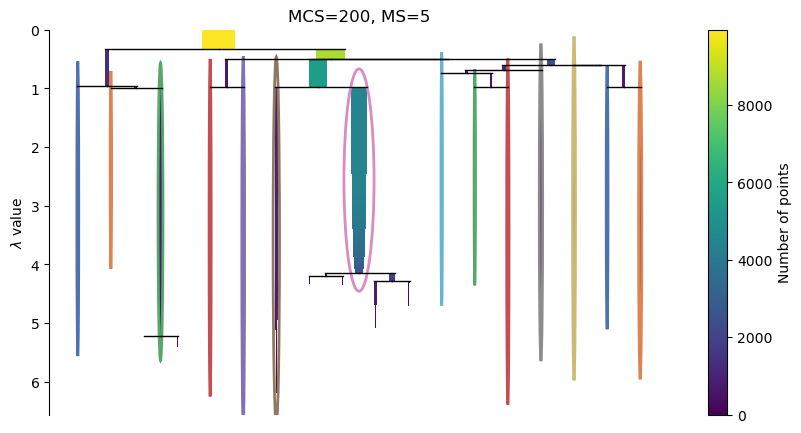

min_samples = 12
Method: hdbscan, Clusters = 14, Noise = 0, DBCV=0.20132, Sil=0.23630, Sep=0.91270


<Figure size 640x480 with 0 Axes>

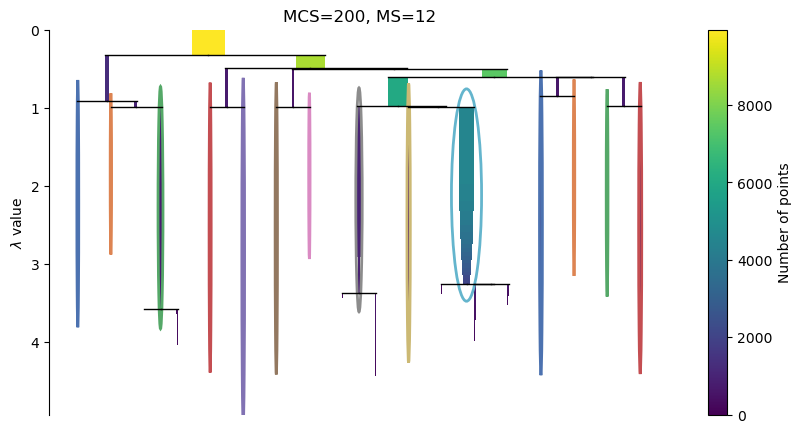

min_samples = 25
Method: hdbscan, Clusters = 14, Noise = 1, DBCV=0.19790, Sil=0.19753, Sep=0.93550


<Figure size 640x480 with 0 Axes>

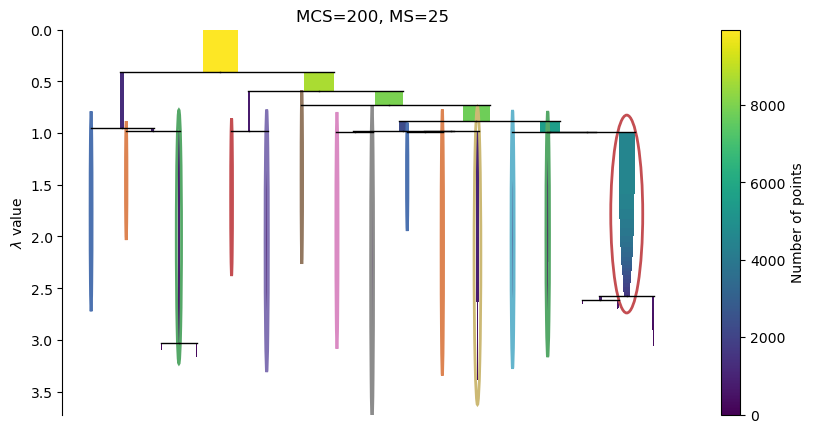

min_samples = 40
Method: hdbscan, Clusters = 14, Noise = 6, DBCV=0.19698, Sil=0.22010, Sep=0.92978


<Figure size 640x480 with 0 Axes>

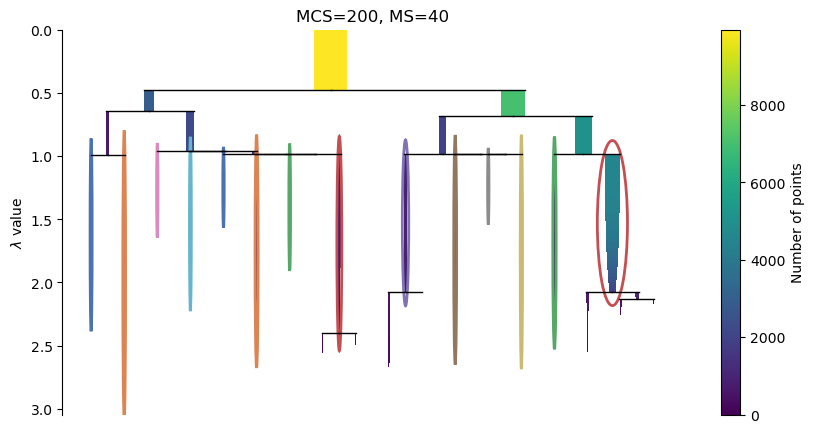

min_samples = 50
Method: hdbscan, Clusters = 14, Noise = 23, DBCV=0.19901, Sil=0.21420, Sep=0.94338


<Figure size 640x480 with 0 Axes>

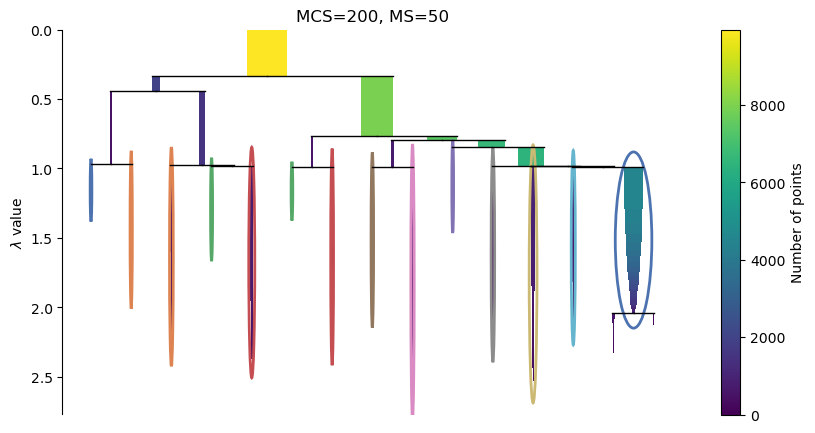

In [ ]:
for i in [1,5,12,25,40,50]:
    print(f"min_samples = {i}")
    hdbscan_test(X_umap3, min_samples=i, min_cluster_size = 200)

min_samples = 1
Method: hdbscan, Clusters = 2, Noise = 501, DBCV=-0.53452, Sil=0.16852, Sep=0.92577


<Figure size 640x480 with 0 Axes>

ValueError: setting an array element with a sequence.

<Figure size 1000x500 with 2 Axes>

min_samples = 5
Method: hdbscan, Clusters = 3, Noise = 6, DBCV=0.03426, Sil=0.14885, Sep=1.41129


<Figure size 640x480 with 0 Axes>

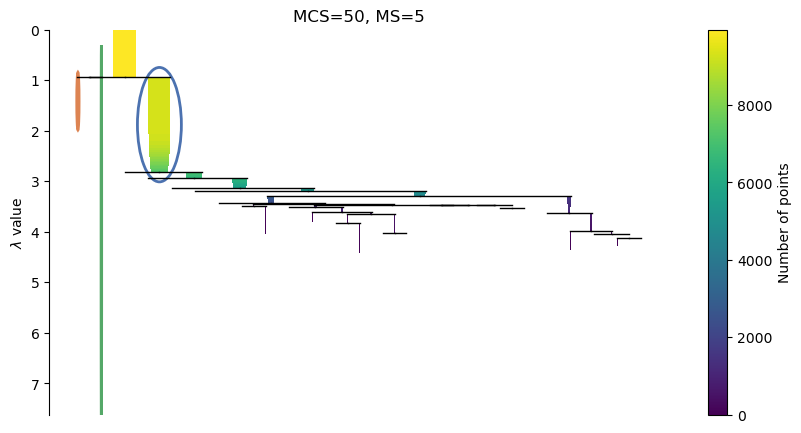

min_samples = 12
Method: hdbscan, Clusters = 3, Noise = 42, DBCV=0.02849, Sil=-0.00233, Sep=2.42949


<Figure size 640x480 with 0 Axes>

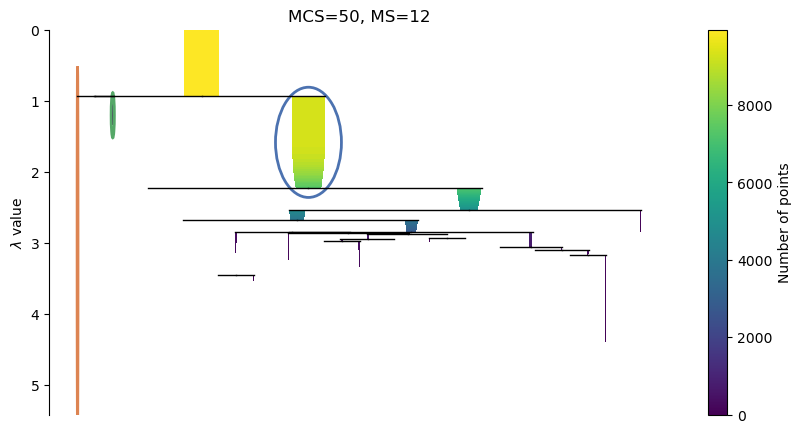

min_samples = 25
Method: hdbscan, Clusters = 3, Noise = 126, DBCV=0.08194, Sil=0.13963, Sep=1.35676


<Figure size 640x480 with 0 Axes>

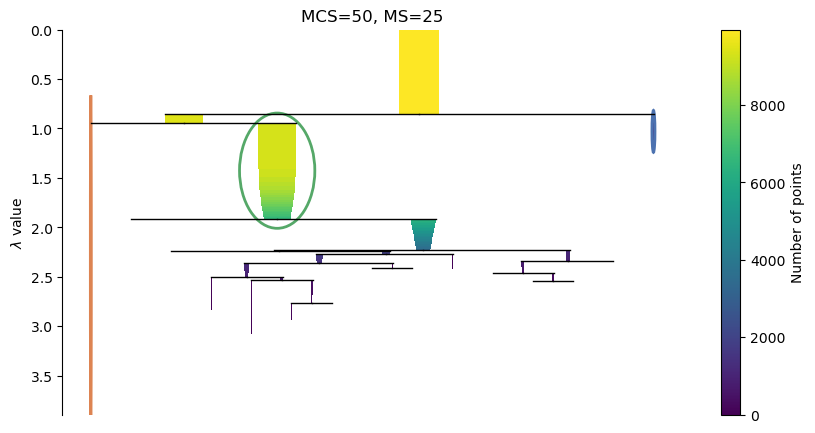

min_samples = 40
Method: hdbscan, Clusters = 3, Noise = 171, DBCV=0.17562, Sil=0.13440, Sep=1.32450


<Figure size 640x480 with 0 Axes>

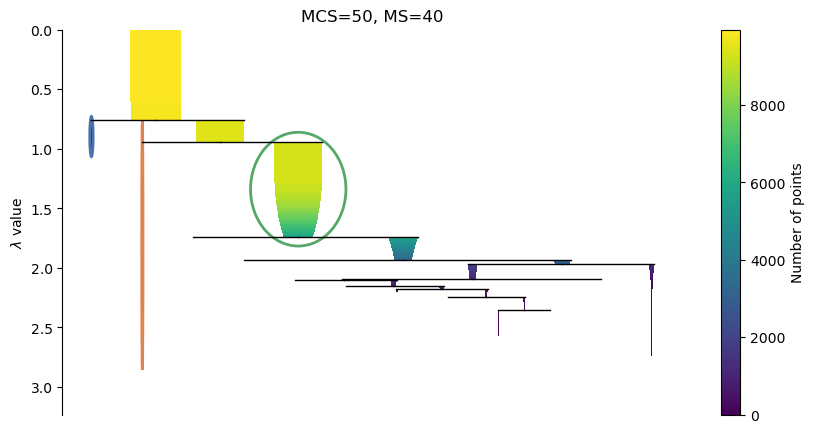

min_samples = 50
Method: hdbscan, Clusters = 3, Noise = 264, DBCV=0.17611, Sil=0.12787, Sep=1.27969


<Figure size 640x480 with 0 Axes>

ValueError: setting an array element with a sequence.

<Figure size 1000x500 with 2 Axes>

In [ ]:
for i in [1,5,12,25,40,50]:
    print(f"min_samples = {i}")
    hdbscan_test(X_umap5, min_samples=i)

min_samples = 1
Method: hdbscan, Clusters = 2, Noise = 529, DBCV=-0.55777, Sil=0.15139, Sep=0.95972


<Figure size 640x480 with 0 Axes>

ValueError: setting an array element with a sequence.

<Figure size 1000x500 with 2 Axes>

min_samples = 5
Method: hdbscan, Clusters = 3, Noise = 4, DBCV=0.11900, Sil=0.14565, Sep=1.38758


<Figure size 640x480 with 0 Axes>

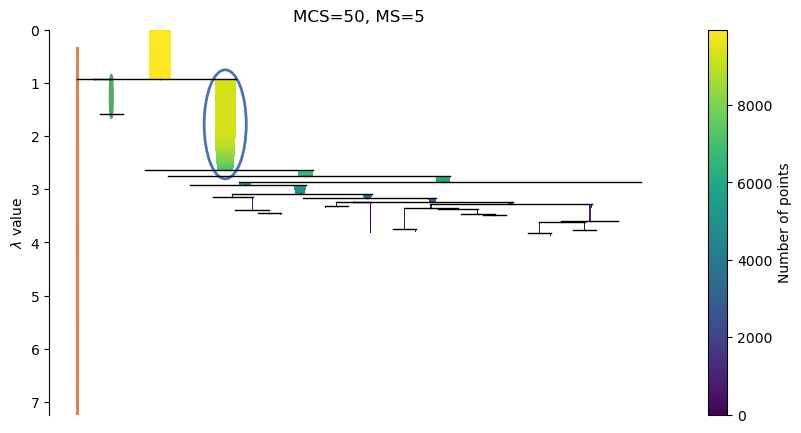

min_samples = 12
Method: hdbscan, Clusters = 3, Noise = 32, DBCV=0.11820, Sil=0.14463, Sep=1.37583


<Figure size 640x480 with 0 Axes>

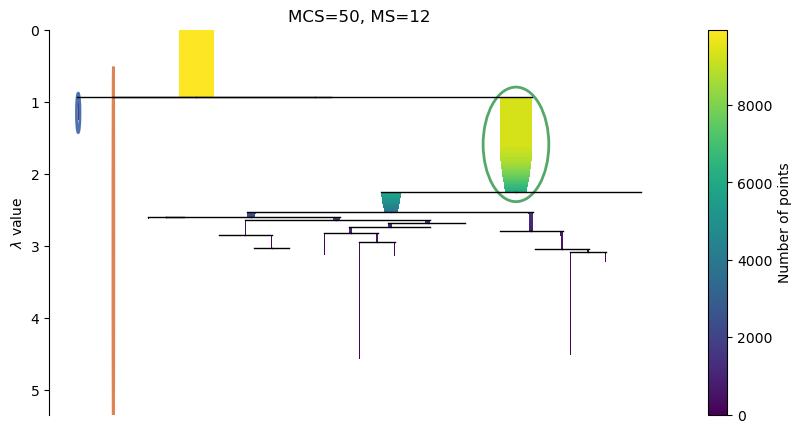

min_samples = 25
Method: hdbscan, Clusters = 3, Noise = 89, DBCV=0.11837, Sil=0.14226, Sep=1.34930


<Figure size 640x480 with 0 Axes>

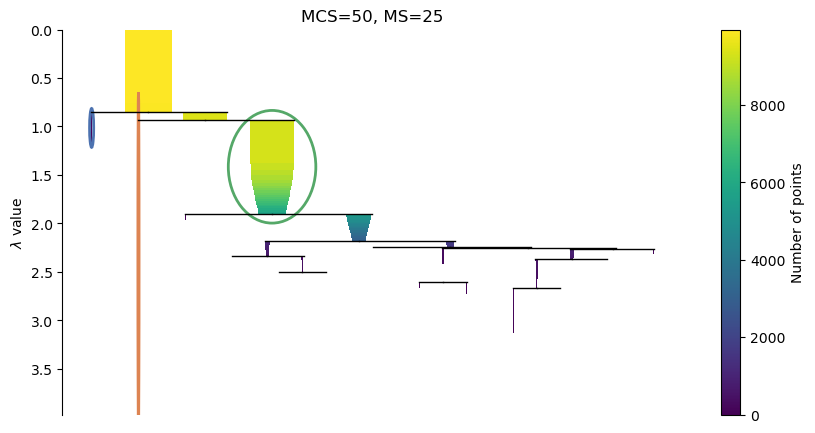

min_samples = 40
Method: hdbscan, Clusters = 3, Noise = 153, DBCV=0.13201, Sil=0.13949, Sep=1.31514


<Figure size 640x480 with 0 Axes>

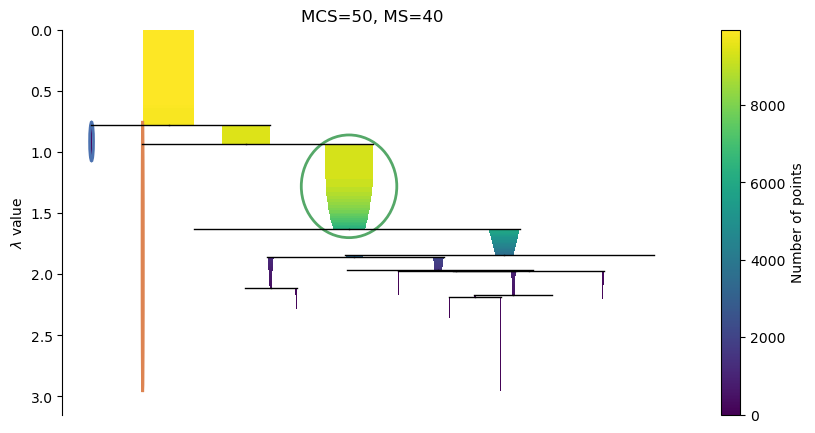

min_samples = 50
Method: hdbscan, Clusters = 3, Noise = 187, DBCV=0.17337, Sil=0.13827, Sep=1.29746


<Figure size 640x480 with 0 Axes>

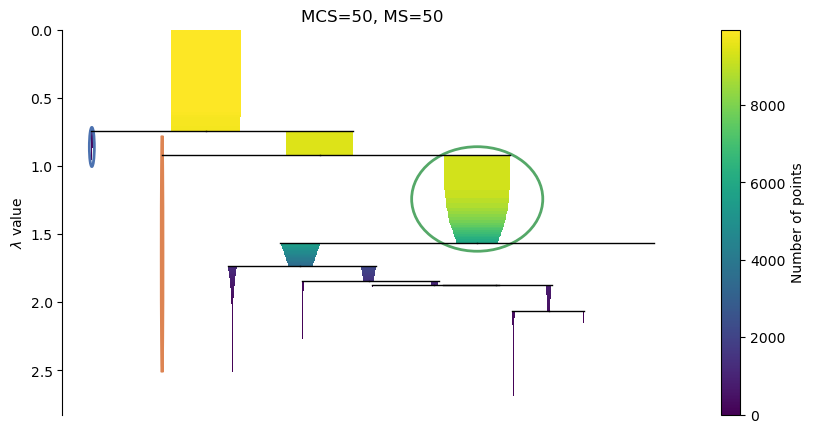

In [ ]:
for i in [1,5,12,25,40,50]:
    print(f"min_samples = {i}")
    hdbscan_test(X_umap8, min_samples=i)

Method: hdbscan, Clusters = 14, Noise = 23, DBCV=0.19869, Sil=0.19144, Sep=0.88933


<Figure size 640x480 with 0 Axes>

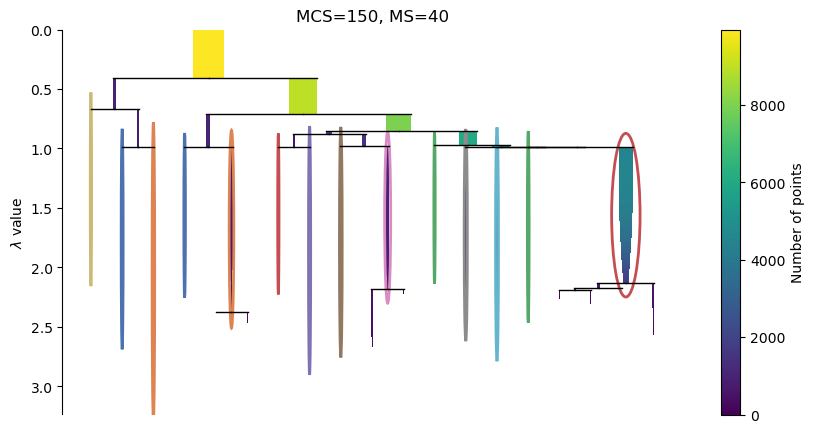

In [ ]:
X = X_umap3
labels = hdbscan_test(X, min_samples=40, min_cluster_size=150)

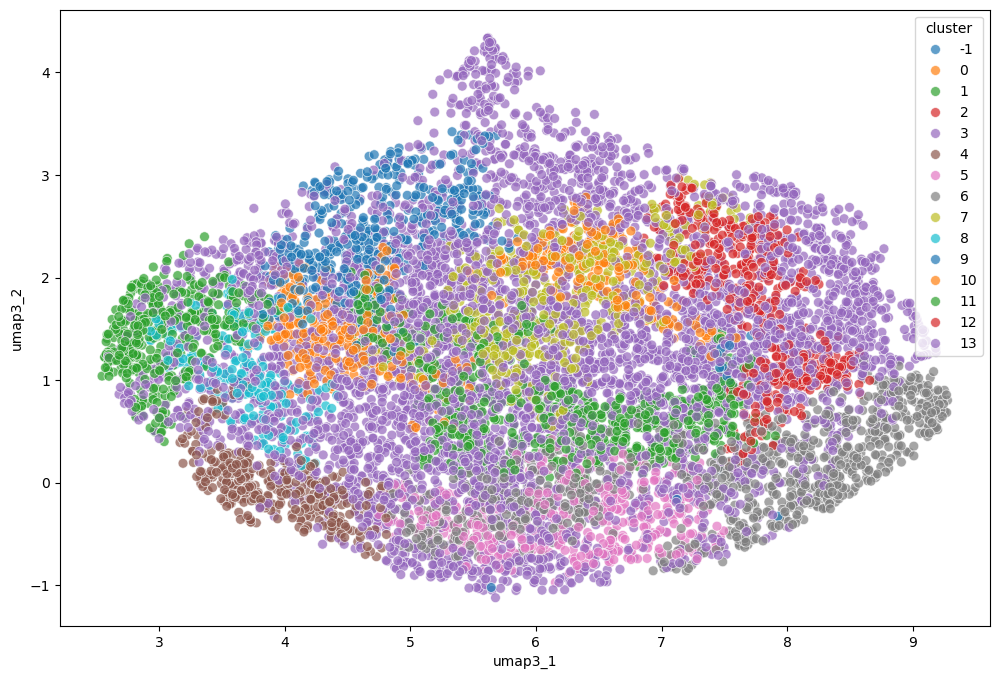

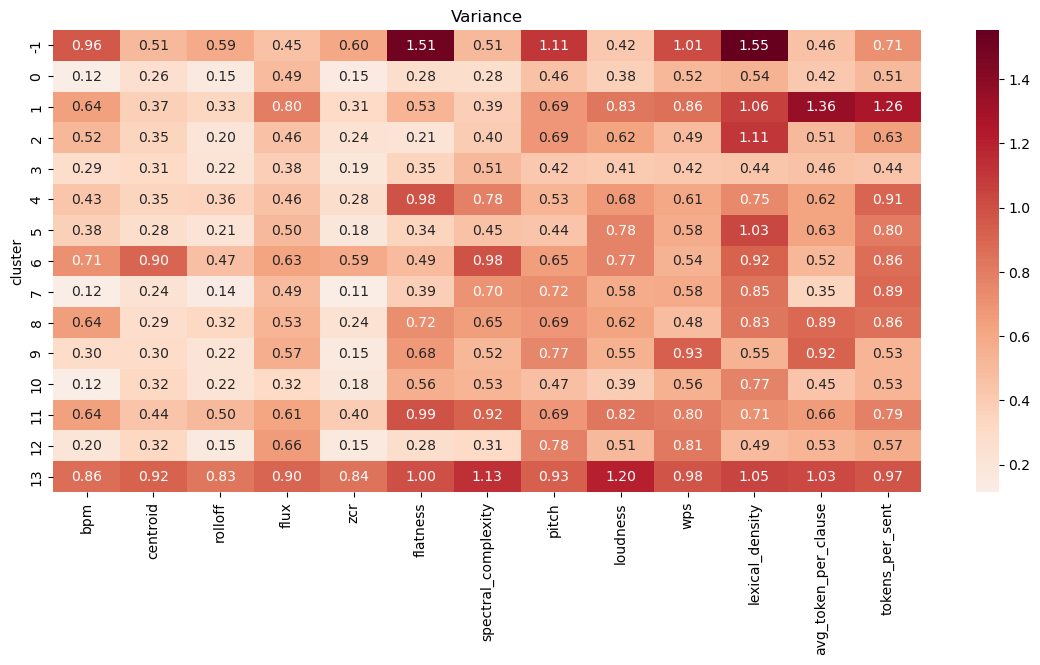

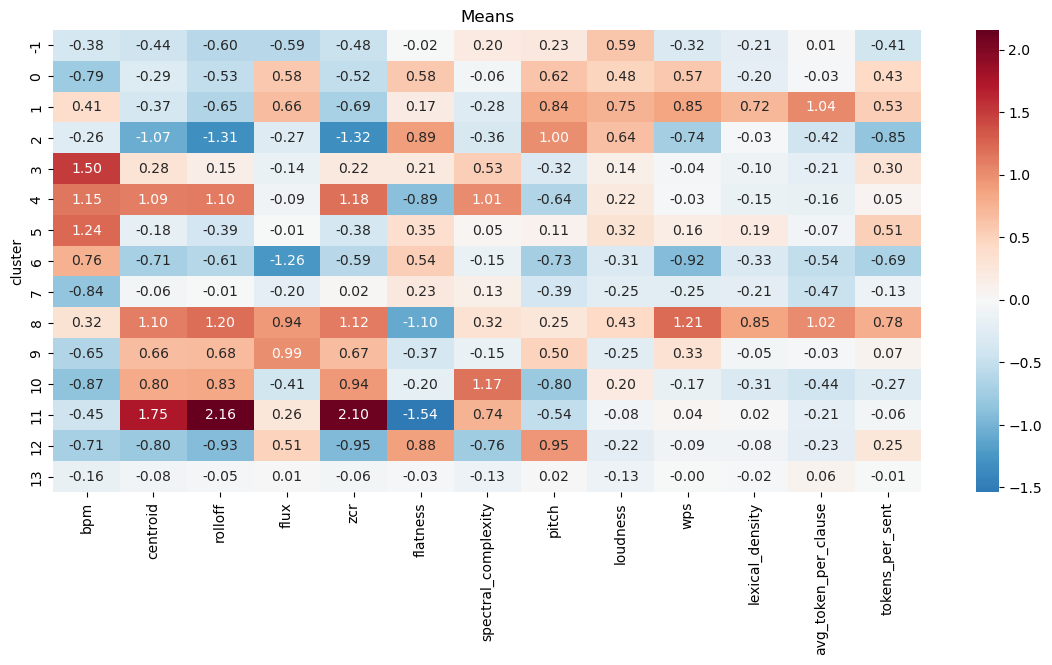

Cluster examples 8:
             title    year
0     ​polka 2 :-/  2021.0
2     ​britney ;-)  2021.0
7            SLATT  2020.0
13  OCCHIO E CROCE  2020.0
15      RAF SIMONS  2020.0
19    ​no love :-)  2021.0
30          ALIENO  2020.0
35           0.25X  2025.0
38      TECKTONiiK  2025.0
42       TIPO DI N  2025.0
name_artist
Dani Faiv        12
Nerone           12
Rosa Chemical    11
Vacca            10
Guè               9
Lazza             9
Geolier           8
Emis Killa        8
Rondodasosa       8
Shiva             8
dtype: int64
Cluster examples 13:
                      title    year
1                     POLKA  2020.0
4                    LONDRA  2020.0
5                    BOHEME  2020.0
6                 LOBBY WAY  2020.0
10                  POLKA 3  2022.0
11               COSANOSTRA  2020.0
12                NUOVI GAY  2020.0
20            ​fantasmi ;-(  2021.0
23  #IORESTOACASA Freestyle  2020.0
24  Ok ok pih roh toh toh !  2019.0
name_artist
Mondo Marcio     149
Guè     

In [ ]:
#labels[labels == 2] = 0

tracks['cluster'] = labels
X['cluster'] = labels
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=X,
    x=X.columns[0],
    y=X.columns[1],
    hue='cluster',          
    palette='tab10',       
    s=50,                   
    alpha=0.7,              
    legend='full'
)

plt.show()

try:
    clust_cols.remove('swear_density_IT')
except Exception as e:
    pass
    
scaler = StandardScaler()
tracks_scaled = pd.DataFrame(
    scaler.fit_transform(tracks[clust_cols]), 
    columns=clust_cols, 
    index=tracks.index
)
tracks_scaled['cluster'] = tracks['cluster']

cluster_variance_std = tracks_scaled.groupby('cluster')[clust_cols].var()

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_variance_std, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title('Variance')
plt.show()

cluster_means = tracks_scaled.groupby('cluster')[clust_cols].mean()
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_means, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title('Means')
plt.show()

for c in tracks['cluster'].unique():
    print(f"Cluster examples {c}:")
    print(tracks[tracks['cluster'] == c][['title', 'year']].head(10)) 
    print(tracks[tracks['cluster'] == c].groupby('name_artist').size().sort_values(ascending=False).head(10))

print("::::::::::::::::::::::::::::")
print(tracks.groupby('cluster')['year'].mean())

print("::::::::::::::::::::::::::::")


score_2 = metrics.silhouette_score(X, labels)
print(f"Silhouette Score: {score_2:.3f}")

db_score = metrics.davies_bouldin_score(X, labels)
print(f"Davies-Bouldin Index: {db_score:.3f}")

dbcv = hdbscan.validity.validity_index(X.values, labels)
print(f"DBCV: {dbcv:.3f}")


top_10_explicit = tracks[tracks['cluster'] == 1].sort_values(by='swear_density_IT', ascending=False).tail(30)

# Print titles and density values for verification
print("Top 10 tracks by profanity density in Cluster 1 (Hardcore/Aggressive):")
print(top_10_explicit[['title', 'swear_density_IT']])


In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=X,
    x=X.columns[0],
    y=X.columns[4],
    hue='cluster',          
    palette='tab10',       
    s=50,                   
    alpha=0.7,              
    legend='full'
)

plt.show()

IndexError: index 4 is out of bounds for axis 0 with size 4

<Figure size 1200x800 with 0 Axes>

In [ ]:
stats = tracks.groupby('cluster')['year'].agg(['count', 'mean', 'min', 'max', 'std']).round(1)
print(stats.to_string())

for c in sorted(tracks['cluster'].unique()):
    top_artists = tracks[tracks['cluster'] == c]['name_artist'].value_counts().head(10).to_dict()
    print(f"Cluster {c}: {top_artists}")

--- TEMPORAL STATISTICS ---
         count    mean     min     max  std
cluster                                    
-1          23  2017.6  2007.0  2025.0  4.8
 0         253  2016.8  1992.0  2025.0  7.2
 1         750  2019.6  1996.0  2025.0  4.0
 2         212  2017.3  1994.0  2025.0  5.8
 3         208  2015.9  2000.0  2025.0  5.4
 4         351  2014.8  2003.0  2025.0  4.8
 5         439  2017.2  1977.0  2025.0  6.5
 6         970  2017.3  1994.0  2025.0  5.9
 7         510  2013.8  1986.0  2025.0  7.2
 8         220  2020.0  2003.0  2025.0  4.4
 9         470  2012.7  1992.0  2025.0  7.6
 10        315  2013.8  1997.0  2025.0  5.2
 11        417  2013.2  1993.0  2025.0  6.0
 12        285  2013.3  1992.0  2025.0  8.8
 13       4531  2015.4  1981.0  2025.0  7.1

--- TOP ARTISTI PER CLUSTER ---
Cluster -1: {'Rancore': 2, 'Lazza': 1, 'Skioffi': 1, 'Mahmood': 1, 'Piotta': 1, 'Guè': 1, 'Rocco Hunt': 1, 'Tedua': 1, 'Il Tre': 1, 'Caparezza': 1}
Cluster 0: {'Guè': 14, 'Gemitaiz': 13, 'Ner